# FIFA World Cup 2026 — Advanced Player Performance Analytics

Analysis pipeline covering:
- Player-season aggregation (per-90 rates, xG/xA)
- **Efficiency modeling**: goals vs expected goals (clinical vs wasteful finishers)
- **Clutch-factor detection**: group stage vs knockout rating swing
- **Multi-factor composite Best XI** (nationality-diverse, position-weighted)
- **Nationality strength ranking**
- Visualizations (Plotly) + CSV exports

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
import json

PATH =  '../data/fifa_world_cup_2026_player_performance.csv'
STAGE_ORDER = ["Group Stage", "Round of 32", "Round of 16", "Quarter Finals",
               "Semi Finals", "Third Place Match", "Final"]
KNOCKOUT_STAGES = ["Round of 16", "Quarter Finals", "Semi Finals", "Final"]

print("Setup complete ✓")

Setup complete ✓


## 2. Load Data & Build Player-Season Aggregates

Collapses the match-by-match rows into one row per player for the tournament, and derives
per-90 rate stats plus the finishing-efficiency metric (`goals - xG`).

In [2]:
df = pd.read_csv(PATH)
df["tournament_stage"] = pd.Categorical(df["tournament_stage"], categories=STAGE_ORDER, ordered=True)

agg = df.groupby(
    ["player_id", "player_name", "nationality", "position", "team", "age", "market_value_eur", "club_name"]
).agg(
    matches=("match_id", "nunique"), minutes=("minutes_played", "sum"),
    goals=("goals", "sum"), assists=("assists", "sum"),
    xg=("expected_goals_xg", "sum"), xa=("expected_assists_xa", "sum"),
    shots=("shots", "sum"), key_passes=("key_passes", "sum"),
    tackles=("tackles", "sum"), interceptions=("interceptions", "sum"),
    recoveries=("recoveries", "sum"), dribbles_succ=("successful_dribbles", "sum"),
    pass_acc=("pass_accuracy", "mean"), saves=("saves", "sum"),
    clean_sheets=("clean_sheet", "sum"), rating=("player_rating", "mean"),
    stamina=("stamina_score", "mean"), top_speed=("top_speed_kmh", "max"),
    distance=("distance_covered_km", "sum"), creativity=("creativity_score", "mean"),
    consistency=("consistency_score", "mean"), clutch=("clutch_performance_score", "mean"),
    pressure=("pressure_resistance", "mean"), offensive=("offensive_contribution", "mean"),
    defensive=("defensive_contribution", "mean"), poty_awards=("player_of_match_awards", "max"),
).reset_index()

agg["per90"] = 90 / agg["minutes"].replace(0, np.nan)
agg["goals_p90"] = agg["goals"] * agg["per90"]
agg["assists_p90"] = agg["assists"] * agg["per90"]
agg["xg_p90"] = agg["xg"] * agg["per90"]
agg["xa_p90"] = agg["xa"] * agg["per90"]
agg["finishing_delta"] = agg["goals"] - agg["xg"]        # clinical vs wasteful finishing
agg["ga_p90"] = agg["goals_p90"] + agg["assists_p90"]
agg["ga_expected_p90"] = agg["xg_p90"] + agg["xa_p90"]
agg["ga_actual_p90"] = agg["ga_p90"]

print(f"Aggregated {len(agg)} unique players across {df['match_id'].nunique()} matches")
agg.head()

Aggregated 1248 unique players across 1050 matches


,player_id,player_name,nationality,position,team,age,market_value_eur,club_name,matches,minutes,...,poty_awards,per90,goals_p90,assists_p90,xg_p90,xa_p90,finishing_delta,ga_p90,ga_expected_p90,ga_actual_p90
0,P00001,Kylian Griezmann,French,Goalkeeper,France,24,16574124,PSV Eindhoven,34,953,...,0,0.094439,0.0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
1,P00002,Antoine Tchouameni,French,Goalkeeper,France,29,53959475,Anderlecht,34,830,...,0,0.108434,0.0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
2,P00003,Ousmane Hernandez,French,Goalkeeper,France,24,4935397,Besiktas,34,922,...,0,0.097614,0.0,0.000000,0.000000,0.000000,0.00,0.000000,0.000000,0.000000
3,P00004,Kylian Camavinga,French,Defender,France,27,3795900,Bayer Leverkusen,34,1299,...,0,0.069284,0.0,0.000000,0.004157,0.000693,-0.06,0.000000,0.004850,0.000000
4,P00005,Antoine Kounde,French,Defender,France,24,21832889,Borussia Dortmund,34,1298,...,0,0.069337,0.0,0.138675,0.012481,0.013867,-0.18,0.138675,0.026348,0.138675


## 3. Clutch Factor — Group Stage vs Knockout Rating Swing

Compares each player's average rating in the Group Stage against Knockout rounds
(Round of 16 onward). A large positive delta means the player elevated their game
when stakes rose — a signal aggregate season stats hide entirely.

In [3]:
group_avg = df[df["tournament_stage"] == "Group Stage"].groupby(
    ["player_id", "player_name", "position", "nationality"])["player_rating"].mean()
knockout_avg = df[df["tournament_stage"].isin(KNOCKOUT_STAGES)].groupby(
    ["player_id", "player_name", "position", "nationality"])["player_rating"].mean()

clutch = pd.concat([group_avg.rename("group_rating"), knockout_avg.rename("knockout_rating")], axis=1).dropna()
clutch["clutch_delta"] = clutch["knockout_rating"] - clutch["group_rating"]
clutch = clutch.reset_index()

minutes_map = agg.set_index("player_id")["minutes"]
clutch = clutch[clutch["player_id"].map(minutes_map) > 400]   # filter for meaningful sample size

top_clutch = clutch.sort_values("clutch_delta", ascending=False).head(10)
top_clutch[["player_name", "nationality", "position", "group_rating", "knockout_rating", "clutch_delta"]].round(2)

,player_name,nationality,position,group_rating,knockout_rating,clutch_delta
678,Raul Lainez,Mexican,Goalkeeper,1.30,5.25,3.95
55,Pedro Torres,Spanish,Defender,3.17,6.48,3.30
878,Mehdi Hazbavi,Iranian,Forward,3.77,6.98,3.21
241,Ricardo Mbabu,Swiss,Defender,3.49,6.66,3.17
502,Angel Gonzalez,Argentine,Defender,2.41,5.54,3.13
496,Emiliano Di Maria,Argentine,Goalkeeper,1.33,4.42,3.09
1215,Amr Marmoush,Egyptian,Midfielder,1.74,4.61,2.87
380,Robin Wahlqvist,Swedish,Midfielder,2.77,5.62,2.85
399,Yusuf Kilicsoy,Turkish,Defender,1.97,4.82,2.85
475,Casemiro Alexandre,Brazilian,Defender,3.65,6.48,2.83


## 4. Multi-Factor Composite Scoring

Each position gets its own weighted formula built from normalized (0-100) stats:

| Position | Key weighted factors |
|---|---|
| GK | Saves (35%), Rating (35%), Clean sheets (30%) |
| DEF | Tackles+Interceptions (35%), Rating (30%), Recoveries (20%), G+A p90 (15%) |
| MID | Creativity (30%), Rating (30%), G+A p90 (25%), Pass accuracy (15%) |
| FWD | G+A p90 (40%), Rating (25%), Clutch score (20%), Finishing delta (15%) |

In [4]:
def normalize(s):
    mn, mx = s.min(), s.max()
    return pd.Series(50.0, index=s.index) if mx == mn else (s - mn) / (mx - mn) * 100

pool = agg[agg["minutes"] >= 270].copy()   # at least ~3 full matches of minutes

def composite_gk(d):
    d = d.copy()
    d["composite"] = (normalize(d["saves"]) * 0.35 + normalize(d["rating"]) * 0.35
                       + normalize(d["clean_sheets"]) * 0.30)
    return d

def composite_def(d):
    d = d.copy()
    d["composite"] = (normalize(d["tackles"] + d["interceptions"]) * 0.35
                       + normalize(d["rating"]) * 0.30 + normalize(d["recoveries"]) * 0.20
                       + normalize(d["ga_p90"]) * 0.15)
    return d

def composite_mid(d):
    d = d.copy()
    d["composite"] = (normalize(d["creativity"]) * 0.30 + normalize(d["rating"]) * 0.30
                       + normalize(d["ga_p90"]) * 0.25 + normalize(d["pass_acc"]) * 0.15)
    return d

def composite_fwd(d):
    d = d.copy()
    d["composite"] = (normalize(d["ga_p90"]) * 0.40 + normalize(d["rating"]) * 0.25
                       + normalize(d["clutch"]) * 0.20 + normalize(d["finishing_delta"]) * 0.15)
    return d

gk = composite_gk(pool[pool["position"] == "Goalkeeper"])
defn = composite_def(pool[pool["position"] == "Defender"])
mid = composite_mid(pool[pool["position"] == "Midfielder"])
fwd = composite_fwd(pool[pool["position"] == "Forward"])

print("Composite scores built ✓")
print(f"GK pool: {len(gk)}  DEF pool: {len(defn)}  MID pool: {len(mid)}  FWD pool: {len(fwd)}")

Composite scores built ✓
GK pool: 144  DEF pool: 432  MID pool: 384  FWD pool: 288


## 5. Data-Driven Best XI (4-3-3, Nationality-Diverse)

Selects the top scorer per position slot, capping at 2 players per nationality
so the XI reflects broad tournament talent rather than one dominant squad.

In [5]:
def pick_best(d, n, max_per_nation=2):
    d = d.sort_values("composite", ascending=False)
    selected, counts = [], {}
    for _, row in d.iterrows():
        nat = row["nationality"]
        if counts.get(nat, 0) < max_per_nation:
            selected.append(row)
            counts[nat] = counts.get(nat, 0) + 1
        if len(selected) >= n:
            break
    return pd.DataFrame(selected)

best_gk = pick_best(gk, 1)
best_def = pick_best(defn, 4)
best_mid = pick_best(mid, 3)
best_fwd = pick_best(fwd, 3)

best_xi = pd.concat([best_gk, best_def, best_mid, best_fwd], ignore_index=True)

print("=" * 60)
print("DATA-DRIVEN BEST XI — FIFA WORLD CUP 2026 (4-3-3)")
print("=" * 60)
best_xi[["player_name", "nationality", "position", "composite", "goals", "assists", "rating"]].round(1)

DATA-DRIVEN BEST XI — FIFA WORLD CUP 2026 (4-3-3)


,player_name,nationality,position,composite,goals,assists,rating
0,Federico Bentancur,Uruguayan,Goalkeeper,80.2,0,0,3.2
1,Ante Budimir,Croatian,Defender,73.7,0,1,5.1
2,Leon Lowe,Jamaican,Defender,72.6,1,3,4.9
3,Abdulrahman Al-Hamdan,Saudi,Defender,69.9,5,0,4.7
4,Pepe Carvalho,Portuguese,Defender,68.2,0,2,5.7
5,Gary Villanueva,Chilean,Midfielder,80.6,3,9,4.8
6,Jamal Koch,German,Midfielder,79.1,5,5,5.1
7,Ronwen Mkhize,South African,Midfielder,77.7,5,7,5.0
8,Memphis Zerrouki,Dutch,Forward,81.9,24,9,4.6
9,Mohannad Majeed,Iraqi,Forward,78.9,15,10,4.3


## 6. Nationality Strength Ranking

Aggregates composite scores across all outfield positions by country
(minimum 8 qualifying players) to rank tournament-wide squad depth.

In [6]:
nat_strength = pd.concat([gk[["nationality", "composite"]], defn[["nationality", "composite"]],
                           mid[["nationality", "composite"]], fwd[["nationality", "composite"]]])
nat_summary = nat_strength.groupby("nationality")["composite"].agg(["mean", "count"]).reset_index()
nat_summary.columns = ["nationality", "avg_composite", "player_count"]
nat_summary = nat_summary[nat_summary["player_count"] >= 8].sort_values("avg_composite", ascending=False)

nat_summary.head(10).round(1)

,nationality,avg_composite,player_count
33,Qatari,46.5,26
14,Dutch,44.2,26
27,Moroccan,43.8,26
29,Panamanian,43.6,26
24,Jamaican,43.5,26
34,Saudi,43.2,26
35,Scottish,42.7,26
7,Cameroonian,42.5,26
23,Italian,41.9,26
20,Ghanaian,41.3,26


## 7. Visualization — Goals vs Expected Goals (Finishing Efficiency)

Top 8 overperformers and top 8 underperformers relative to xG
(minimum 10 shots, 300+ minutes played).

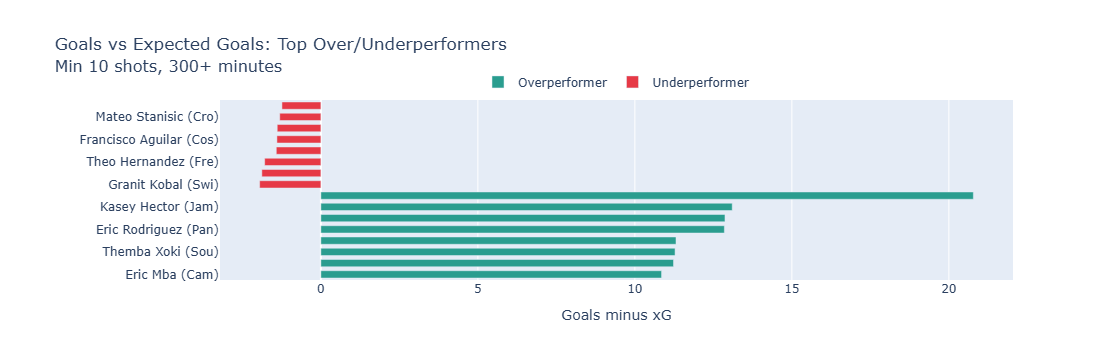

In [7]:
pool_shots = agg[(agg["minutes"] > 300) & (agg["shots"] >= 10)].copy()
top_over = pool_shots.sort_values("finishing_delta", ascending=False).head(8)
top_under = pool_shots.sort_values("finishing_delta", ascending=True).head(8)
combo = pd.concat([top_over, top_under]).sort_values("finishing_delta")
combo["category"] = combo["finishing_delta"].apply(lambda v: "Overperformer" if v >= 0 else "Underperformer")
combo["label"] = combo["player_name"] + " (" + combo["nationality"].str[:3] + ")"

fig1 = go.Figure()
for cat, color in [("Overperformer", "#2A9D8F"), ("Underperformer", "#E63946")]:
    sub = combo[combo["category"] == cat]
    fig1.add_trace(go.Bar(x=sub["finishing_delta"], y=sub["label"], orientation="h",
                           marker_color=color, name=cat, cliponaxis=False))
fig1.update_layout(
    title={"text": "Goals vs Expected Goals: Top Over/Underperformers<br>"
                    "<span style='font-size: 16px; font-weight: normal;'>Min 10 shots, 300+ minutes</span>"},
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
    bargap=0.35, margin=dict(l=220))
fig1.update_xaxes(title_text="Goals minus xG")
fig1.write_image("../outputs/finishing_delta.png", width=1100, height=750)
fig1.show()

## 8. Visualization — Clutch Performers

Players with the biggest rating jump entering the knockout stage.

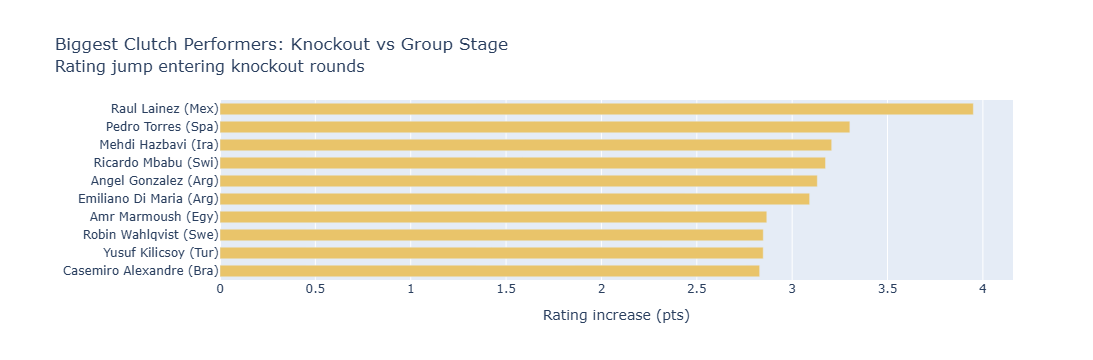

In [8]:
top_clutch_plot = top_clutch.sort_values("clutch_delta")
top_clutch_plot["label"] = top_clutch_plot["player_name"] + " (" + top_clutch_plot["nationality"].str[:3] + ")"

fig2 = go.Figure()
fig2.add_trace(go.Bar(x=top_clutch_plot["clutch_delta"], y=top_clutch_plot["label"], orientation="h",
                       marker_color="#E9C46A", cliponaxis=False))
fig2.update_layout(
    title={"text": "Biggest Clutch Performers: Knockout vs Group Stage<br>"
                    "<span style='font-size: 16px; font-weight: normal;'>Rating jump entering knockout rounds</span>"},
    bargap=0.35, margin=dict(l=220))
fig2.update_xaxes(title_text="Rating increase (pts)")
fig2.write_image("../outputs/clutch_factor.png", width=1000, height=650)
fig2.show()

## 9. Visualization — Attacking Efficiency Scatter

Actual vs expected goals+assists per 90 minutes for forwards & midfielders (500+ mins).
Points above the dashed line outperform their underlying chances; points below underperform.

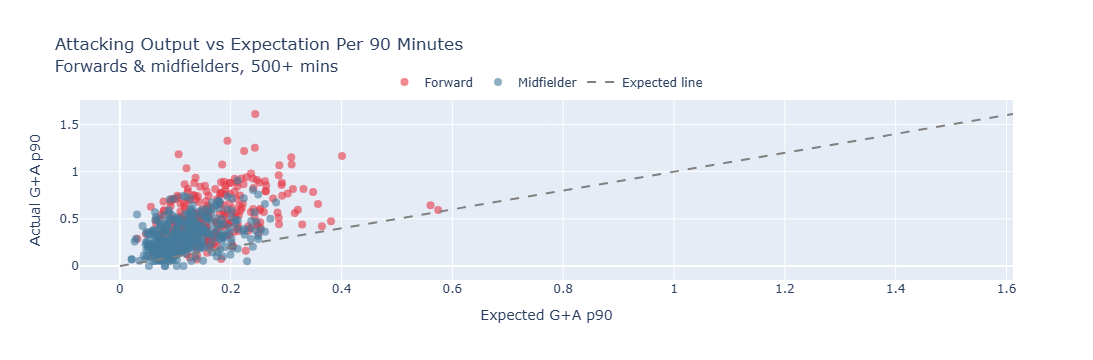

In [9]:
attackers = agg[(agg["position"].isin(["Forward", "Midfielder"])) & (agg["minutes"] > 500)].copy()

fig3 = go.Figure()
for pos, color in [("Forward", "#E63946"), ("Midfielder", "#457B9D")]:
    sub = attackers[attackers["position"] == pos]
    fig3.add_trace(go.Scatter(x=sub["ga_expected_p90"], y=sub["ga_actual_p90"], mode="markers",
                               marker=dict(size=8, color=color, opacity=0.6), name=pos,
                               text=sub["player_name"],
                               hovertemplate="%{text}<br>Exp: %{x:.2f}<br>Actual: %{y:.2f}"))
max_val = max(attackers["ga_expected_p90"].max(), attackers["ga_actual_p90"].max())
fig3.add_trace(go.Scatter(x=[0, max_val], y=[0, max_val], mode="lines",
                           line=dict(dash="dash", color="gray"), name="Expected line"))
fig3.update_layout(
    title={"text": "Attacking Output vs Expectation Per 90 Minutes<br>"
                    "<span style='font-size: 16px; font-weight: normal;'>Forwards & midfielders, 500+ mins</span>"},
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5))
fig3.update_xaxes(title_text="Expected G+A p90")
fig3.update_yaxes(title_text="Actual G+A p90")
fig3.write_image("../outputs/efficiency_scatter.png", width=1000, height=750)
fig3.show()

## 10. Export Results

Saves all analysis tables to CSV for downstream use.

In [10]:
agg.to_csv("../outputs/player_aggregates.csv", index=False)
best_xi.to_csv("../outputs/best_xi.csv", index=False)
nat_summary.to_csv("../outputs/nationality_strength.csv", index=False)
combo.to_csv("../outputs/xg_over_underperformers.csv", index=False)
top_clutch.to_csv("../outputs/clutch_performers.csv", index=False)

print("Exports complete:")
print("- player_aggregates.csv")
print(" - best_xi.csv")
print(" - nationality_strength.csv")
print(" - xg_over_underperformers.csv")
print(" - clutch_performers.csv")

Exports complete:
- player_aggregates.csv
 - best_xi.csv
 - nationality_strength.csv
 - xg_over_underperformers.csv
 - clutch_performers.csv
